In [52]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import glob

from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
from tes.algo_umap import UmapAlgo
from tes.algo_partial_full import AlgoParFull
from tes.commAnalysis import CommPercentages

from scipy.optimize import curve_fit


In [53]:
analyse = AnalysisFunc()
reader = DataRead()
algo = UmapAlgo()
algo_pf = AlgoParFull()
comm_partcptn = CommPercentages()

### Read ST and FPT data from results
- This data from older simulations for which there is no NC data
- Change this analysis data once you fine fit it

In [3]:
params = reader.data_read_pkl(f'results/partial_full_data_200_itr/FN')

In [ ]:
params[1].keys()
# 1 for partial
# 2 for full


dict_keys(['t_t', 'fp_t', 's_t', 'cov'])

In [34]:
part_fpt=params[1]["fp_t"]
part_fpt=[x for x in part_fpt if x!=0]
full_fpt=params[2]["fp_t"]  
full_fpt=[x for x in full_fpt if x!=0]

full_st=params[2]["s_t"]
full_st=[x for x in full_st if x!=0]
part_st=params[1]["s_t"]
part_st=[x for x in part_st if x!=0]

In [35]:
min(full_fpt)

25.0

In [ ]:
full_st

#### Explaination behind fitting CCDF
Sort intervals → put waiting times in order.
Compute CCDF → probability of waiting longer than each time.
Take log → so exponential becomes linear.
Fit a line → slope ≈ λ
Plot points + line → check visually if it’s straight.
Return λ → estimated rate of arrivals.
Imagine you’re waiting for ice cream 🍦. Sometimes you wait 2 minutes, sometimes 5 minutes, sometimes 10 minutes. You write down all the waiting times.
Now, if the ice cream man comes randomly (like rolling dice), the times you wait should follow a special "random waiting pattern" called exponential distribution.
How do we check?
We line up all the waiting times from smallest to biggest.
We ask: “What’s the chance I wait longer than this time?” (that’s the CCDF: probability of waiting more than t).
If we draw this chance on a special graph (logarithmic scale), exponential waiting times make a straight line.
If it’s straight, we say: “Yes! My waiting times are exponential.”
The slope of that line tells us how fast the ice cream man usually comes (that’s λ, the rate).

In [69]:
def expo_plot_two_lines(intervals, ax, label, split_index=None):
    # Sort data
    intervals = np.sort(intervals)
    n = len(intervals)

    # CCDF: P(T > t)
    ccdf = 1.0 - np.arange(1, n + 1) / n

    # Remove zero values (log undefined)
    mask = ccdf > 0
    intervals = intervals[mask]
    ccdf = ccdf[mask]

    # Log of CCDF
    log_ccdf = np.log(ccdf)

    # Default split: halfway
    if split_index is None:
        split_index = len(intervals) // 2

    # First segment fit
    slope1, intercept1 = np.polyfit(intervals[:split_index], log_ccdf[:split_index], 1)
    lam1 = -slope1

    # Second segment fit
    slope2, intercept2 = np.polyfit(intervals[split_index:], log_ccdf[split_index:], 1)
    lam2 = -slope2

    # Plot scatter
    ax.scatter(intervals, log_ccdf, s=20, alpha=0.7, label=label)

    # Plot first line
    ax.plot(
        intervals[:split_index],
        slope1 * intervals[:split_index] + intercept1,
        'r-',
        label=f'Fit 1 (λ ≈ {lam1:.3f})'
    )

    # Plot second line
    ax.plot(
        intervals[split_index:],
        slope2 * intervals[split_index:] + intercept2,
        'g-',
        label=f'Fit 2 (λ ≈ {lam2:.3f})'
    )

    ax.set_ylabel("log P(T > t)")
    ax.set_title(f"Log-CCDF {label} (2 fits)")
    ax.legend()


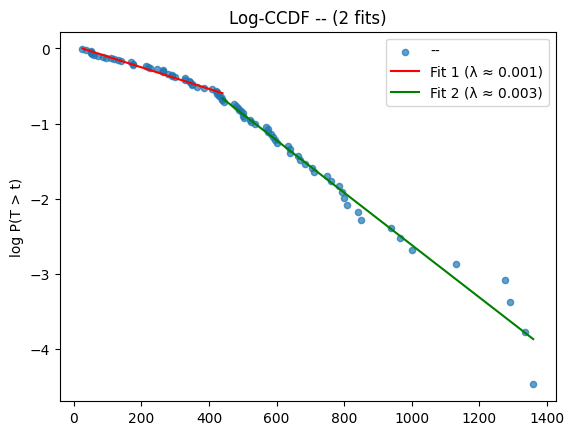

In [70]:
expo_plot_two_lines(full_fpt, plt.gca(), "--")

## Get all data from folder

In [76]:
data_folder = Path('../../data/results/partial_full_data_200_itr/')
files = list(data_folder.glob('*'))
# files = glob.glob(str(data_folder / "*.pkl"))
# params = reader.data_read_pkl(f'results/partial_full_data_200_itr/FN')

In [77]:
files

[WindowsPath('../../data/results/partial_full_data_200_itr/BLA'),
 WindowsPath('../../data/results/partial_full_data_200_itr/ENTI'),
 WindowsPath('../../data/results/partial_full_data_200_itr/FN'),
 WindowsPath('../../data/results/partial_full_data_200_itr/LHA'),
 WindowsPath('../../data/results/partial_full_data_200_itr/LSc'),
 WindowsPath('../../data/results/partial_full_data_200_itr/MOB'),
 WindowsPath('../../data/results/partial_full_data_200_itr/MOp'),
 WindowsPath('../../data/results/partial_full_data_200_itr/MOs'),
 WindowsPath('../../data/results/partial_full_data_200_itr/ORB'),
 WindowsPath('../../data/results/partial_full_data_200_itr/PERI'),
 WindowsPath('../../data/results/partial_full_data_200_itr/PIR'),
 WindowsPath('../../data/results/partial_full_data_200_itr/RE')]

Processing file: ..\..\data\results\partial_full_data_200_itr\BLA


TypeError: '<' not supported between instances of 'dict' and 'dict'

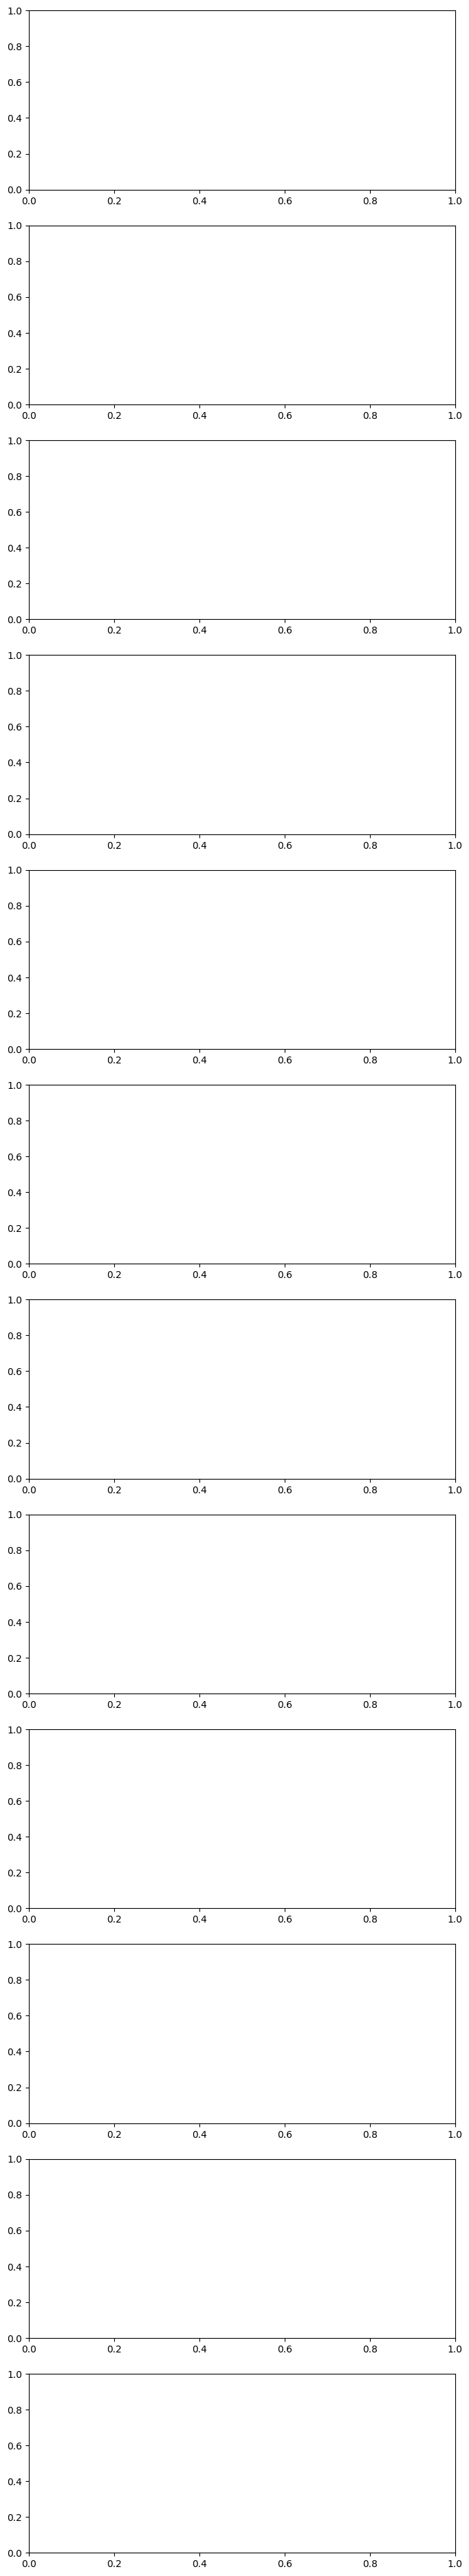

In [ ]:
fig,axes = plt.subplots(len(files),1, figsize=(8,4*len(files)))
for ax, file in zip(axes, files):
    print(f'Processing file: {file}')
    with open(file, "rb") as f:
        data = pickle.load(f)

    expo_plot_two_lines(data,ax,'network')
plt.tight_layout()

